### Question 2: NYC Flight Data Analysis
You are provided with a large dataset containing information on NYC flights from the year 2013.

Before you begin, ensure that you have the following Python libraries installed. (Might be useful to create a virtual environment).

In [2]:
import numpy as np
import pandas as pd
from scipy import stats, integrate
import matplotlib.pyplot as plt
import seaborn as sns

The dataset includes various details such as departure times, delays, carriers, and destinations. Below is a sample of the data:

In [4]:
flight_data=pd.read_csv("./flight_data.csv")
flight_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,1/1/2013 5:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,1/1/2013 5:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,1/1/2013 5:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,1/1/2013 5:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,1/1/2013 6:00


### Part 1 - Data cleaning

1. Identify Missing Values
    - 1.1 Find and display all rows in the dataset that contain at least one null value in any column.
2. Handle Missing Values
    - 1.2 Remove (omit) all rows where a null (NaN) value is present in any column.


In [9]:
# Find and display all rows in the dataset that contain at least one null value in any column
null_rows = flight_data[flight_data.isnull().any(axis=1)]
print(null_rows)

# Remove all rows where a null value is present in any column
clean_data = flight_data.dropna()

        year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
471     2013      1    1    1525.0            1530       -5.0    1934.0   
477     2013      1    1    1528.0            1459       29.0    2002.0   
615     2013      1    1    1740.0            1745       -5.0    2158.0   
643     2013      1    1    1807.0            1738       29.0    2251.0   
725     2013      1    1    1939.0            1840       59.0      29.0   
...      ...    ...  ...       ...             ...        ...       ...   
336771  2013      9   30       NaN            1455        NaN       NaN   
336772  2013      9   30       NaN            2200        NaN       NaN   
336773  2013      9   30       NaN            1210        NaN       NaN   
336774  2013      9   30       NaN            1159        NaN       NaN   
336775  2013      9   30       NaN             840        NaN       NaN   

        sched_arr_time  arr_delay carrier  flight tailnum origin dest  \
471               1805    

### Part 2 - Data Analysis:

1. Identify top 10 destination airports from NYC 

    1. Display a table showing each of these airports along with the number of flights to each.

    2. Create a plot to visualize this data. Choose a chart type that you find most appropriate. Ensure that your plot includes: 
    - a clear title 
    - labeled axes 
    - legend (if applicable)

2. Calculate the average departure delay for each carrier on a monthly basis

    Present this data in a table with the following three columns:
    - Carrier
    - Month (formatted as MM-MMMM, e.g., 03-March)
    - Average Departure Delay

Top 10 Destination Airports from NYC:
   Destination Airport  Number of Flights
1                  ORD              17283
2                  ATL              17215
3                  LAX              16174
4                  BOS              15508
5                  MCO              14082
6                  CLT              14064
7                  SFO              13331
8                  FLL              12055
9                  MIA              11728
10                 DCA               9705


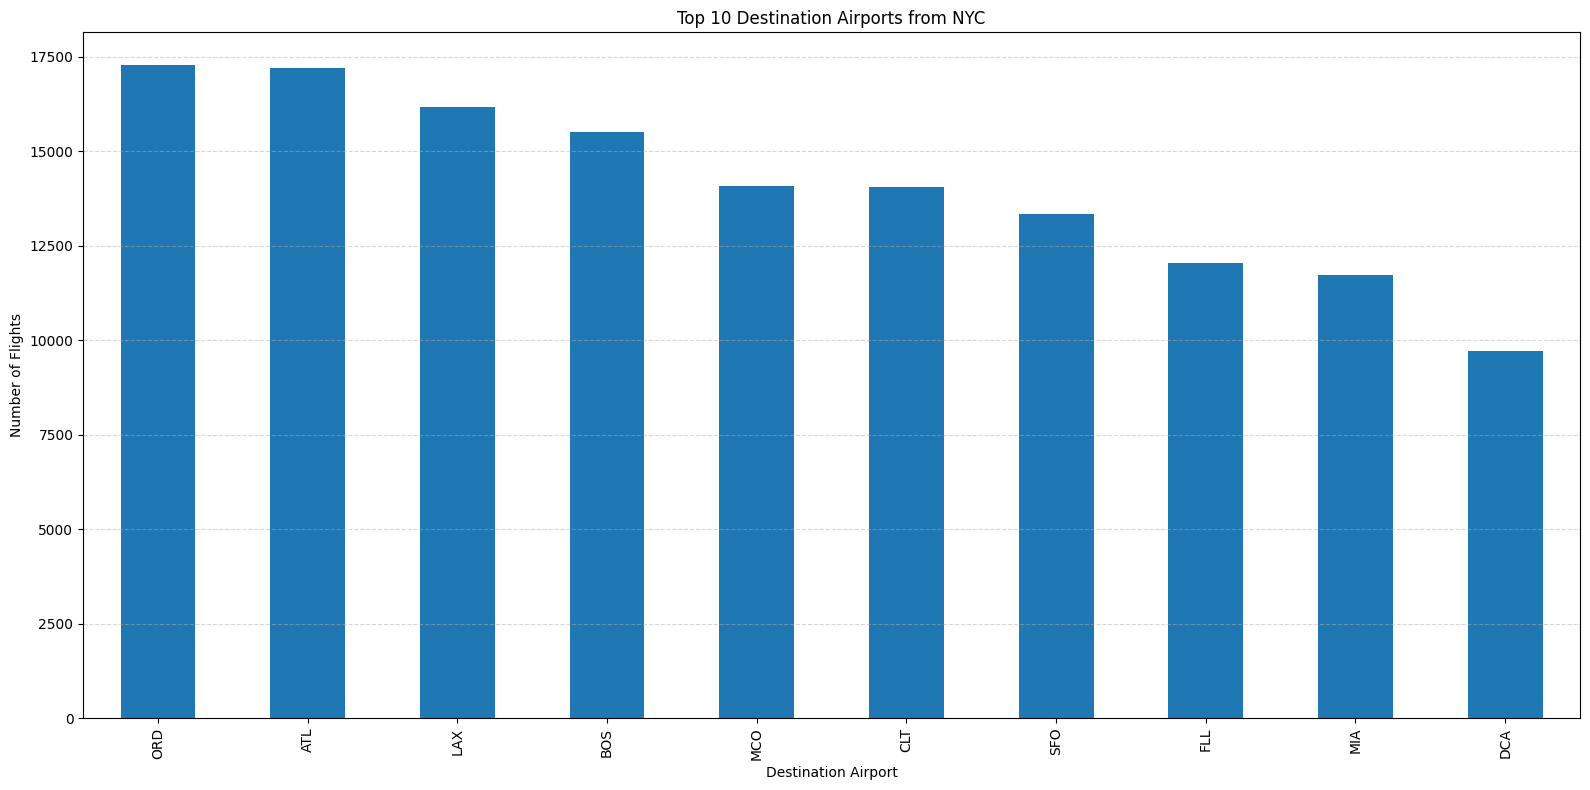

In [21]:

# Create the table using a dataframe for readability
top_destinations = flight_data['dest'].value_counts().head(10)
top_destinations_table = top_destinations.reset_index()
top_destinations_table.columns = ['Destination Airport', 'Number of Flights']
top_destinations_table.index = top_destinations_table.index + 1

# Display the table of top 10 destination airports
print("Top 10 Destination Airports from NYC:")
print(top_destinations_table)

# Visualize the top 10 destination airports as a bar chart
plt.figure(figsize=(16, 8))
top_destinations.plot(kind='bar')
plt.title('Top 10 Destination Airports from NYC')
plt.xlabel('Destination Airport')
plt.ylabel('Number of Flights')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
delay_avg = (
    flight_data
    .assign(
        Month=flight_data['month'].apply(lambda x: f"{x:02d}-{pd.Timestamp(2023, x, 1).strftime('%B')}")
    )
    .groupby(['carrier', 'Month'])['dep_delay']
    .mean()
    .reset_index()
    .rename(columns={'carrier': 'Carrier', 'dep_delay': 'Average Departure Delay'})
    .round({'Average Departure Delay': 2})
)
delay_avg.index = delay_avg.index + 1
print(delay_avg)

    Carrier         Month  Average Departure Delay
1        9E    01-January                    16.88
2        9E   02-February                    16.49
3        9E      03-March                    13.41
4        9E      04-April                    13.57
5        9E        05-May                    22.67
..      ...           ...                      ...
181      YV     08-August                    19.07
182      YV  09-September                     8.88
183      YV    10-October                    20.00
184      YV   11-November                    10.52
185      YV   12-December                    13.11

[185 rows x 3 columns]


### Part 3 - Consistency in On-Time Performance

1. Determine which carrier has the most consistent on-time performance, defined as having the smallest variance in departure delays.

2. Instructions:

    1. Data Cleaning: Ensure that the dataset is cleaned as in Part 1 before performing this analysis.

    2. Variance Calculation: You must **not** use any of the libraries imported above (numpy, pandas, scipy, etc.) for this part. Implement your own function to calculate the variance of departure delays for each carrier.

3. Deliverable

    1. Identify and display the carrier with the smallest variance in departure delays.

    2. Provide a brief explanation of your findings.

In [ ]:
import csv

# boilerplate for file parsing
flight_records = []

# Read the dataset into a list of dictionaries
with open('flight_data.csv', mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        flight_records.append(row)

# Filter out rows
records_filtered = [
    row for row in flight_records
    if row['dep_delay'] not in ('', 'NA') and row['dep_delay'] is not None
]

# Group departure delays
delays = {}
for row in records_filtered:
    carrier = row['carrier']
    dep_delay = float(row['dep_delay'])
    if carrier not in delays:
        delays[carrier] = []
    delays[carrier].append(dep_delay)

# Implement a custom variance calculation function
def calculate_var(data):
    if len(data) < 2:
        return float('inf')
    mean = sum(data) / len(data)
    variance = sum((x - mean) ** 2 for x in data) / len(data)
    return variance

# Calculate the variance of departure delays for each carrier
carrier_var = {}
for carrier, delays in delays.items():
    carrier_var[carrier] = calculate_var(delays)

# Identify the carrier with the smallest variance
most_consistent_car = min(carrier_var, key=carrier_var.get)
smallest_var = carrier_var[most_consistent_car]

# Display the result
print(f"The carrier with the most consistent on-time performance is '{most_consistent_car}' "
      f"with a variance in departure delays of {smallest_var:.2f}.")


The carrier with the most consistent on-time performance is 'US' with a variance in departure delays of 787.12.


(Optional) Check your findings by using the numpy library to preform the same analysis.